In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784",version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [2]:
mnist["data"]

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
mnist["target"]

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: category
Categories (10, str): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [4]:
mnist["data"].shape

(70000, 784)

In [5]:
mnist["target"].shape

(70000,)

In [6]:
import numpy as np 
from matplotlib import pyplot as plt

In [7]:
data = mnist["data"]
target = mnist["target"]

In [60]:
data_target_merged = pd.concat([data,target], axis=1)
data_target_merged

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


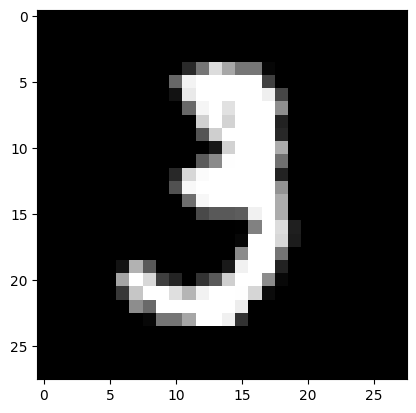

In [61]:
first_img = data.iloc[10,:].values
img = first_img.reshape(28,28)
plt.imshow(img, cmap="gray")

In [62]:
import torch
import torchvision.transforms as transforms
from torchvision.utils import save_image
from matplotlib import pyplot as plt
import cv2 as cv

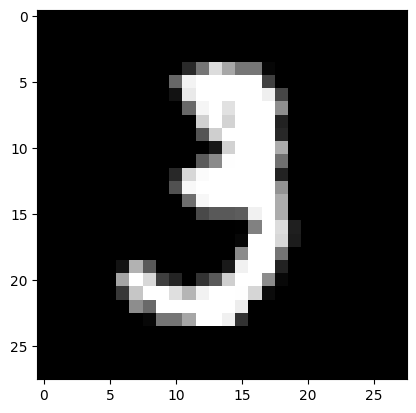

In [63]:
Horizontal_Flipping_Transformation = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5) 
])
img = img.astype("uint8")
flipped_img = Horizontal_Flipping_Transformation(img)
plt.imshow(np.array(flipped_img), cmap="gray")

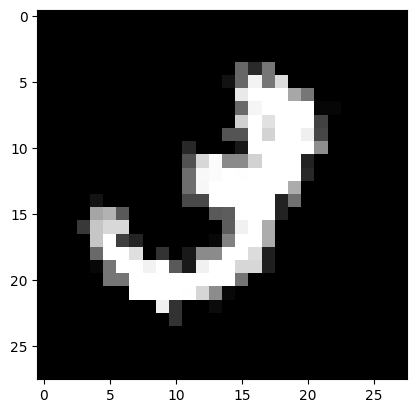

In [64]:
Rotate_Transformation = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(degrees=66)
])

rotated_img = Rotate_Transformation(img)
plt.imshow(rotated_img,cmap="gray")

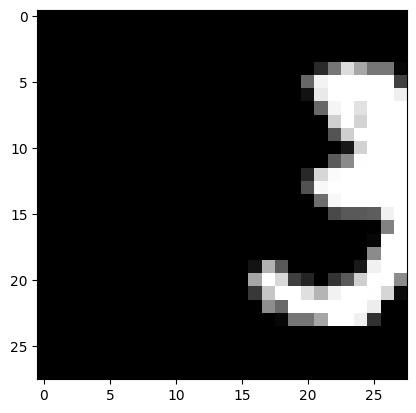

In [65]:
from scipy.ndimage import shift

shifted_img = shift(img, shift=[0, 10]) 
plt.imshow(shifted_img, cmap="gray")

In [72]:
import random
import pandas as pd 

def rand_rot_img_df(dataset,max_degree,min_degree,amount_of_rots):
    new_rows = []
    for i in range(dataset.shape[0]):
        img_cols = dataset.iloc[i,:].values
        img_label = dataset.iloc[i,-1]
        img = img_cols[:-1].reshape(28,28)
        img = img.astype("uint8")
        for c in range(amount_of_rots):
            random_i = random.randint(int(max_degree),int(min_degree))
            Rotate_Transformation = transforms.Compose([
                transforms.ToPILImage(),
                transforms.RandomRotation(degrees=random_i)
                ])
            rotated_img = Rotate_Transformation(img)  
            img_flat = np.array(rotated_img).flatten()
            img_flat_with_label = np.append(img_flat, img_label)
            new_rows.append(pd.Series(img_flat_with_label, index=dataset.columns))
    augmented_df = pd.DataFrame(new_rows)
    return augmented_df

In [73]:
rotated_imgs = rand_rot_img_df(data_target_merged,0,60,4)
rotated_imgs.shape

(280000, 785)

In [77]:
rotated_imgs.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


2


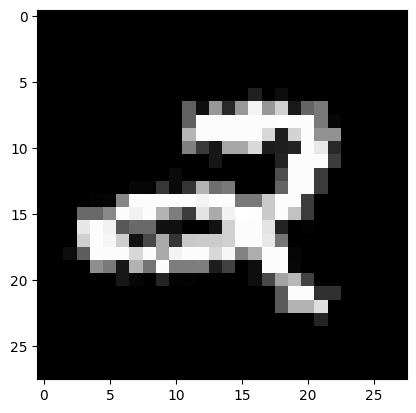

In [92]:
first_img = rotated_imgs.iloc[20,:].values
arr = first_img[:-1]
print(first_img[-1])
img = arr.reshape(28,28).astype(float)
plt.imshow(img,cmap="gray")

In [93]:
def shift_pixels(dataset,min_shift,max_shift,amount_of_shifts):
    new_rows = []
    for i in range(dataset.shape[0]):
        img_cols = dataset.iloc[i,:].values
        img_label = dataset.iloc[i,-1]
        img = img_cols[:-1].reshape(28,28)
        img = img.astype("uint8")
        for c in range(amount_of_shifts):
            random_i = random.randint(int(min_shift), int(max_shift))
            shifted_img = shift(img, shift=[0, random_i])
            img_flat = np.array(rotated_img).flatten()
            img_flat_with_label = np.append(img_flat, img_label)
            new_rows.append(pd.Series(img_flat_with_label, index=dataset.columns))
    augmented_df = pd.DataFrame(new_rows)
    return augmented_df

In [95]:
shifted_imgs = shift_pixels(data_target_merged,5,10,4)
shifted_imgs.shape

(280000, 785)

In [98]:
merged_df = pd.concat([data_target_merged,shifted_imgs,rotated_imgs],axis=0)
merged_df.shape

(630000, 785)

In [99]:
merged_df.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [ ]:
from sklearn.